# Hydro Storage Scheduling under Price Uncertainty (TAS1)

Tasmania's electricity is ~80% hydro. The reservoirs are not just
generation — they are *energy storage*, and Hydro Tasmania's daily
problem is the canonical one in energy economics: when do you let the
water through, and when do you hold it back?

This notebook builds a small but honest version of that problem on
real TAS1 dispatch prices:

1. Fit a probabilistic model to the price history so we can sample
   plausible future paths instead of pretending we know what's coming.
2. Define a single-reservoir simulator with linear water dynamics.
3. Solve the optimal dispatch policy via stochastic dynamic programming
   on a discretised state, then compare it to a greedy threshold policy
   and a perfect-foresight LP that has full advance knowledge of the
   prices.
4. Run all three policies on out-of-sample price paths and compare both
   the mean revenue and the worst-case (CVaR) tail.

Like the other capstones, the notebook is laid out as a short paper —
**Introduction**, **Data**, **Methods**, **Results**, **Conclusion** —
and every plot is read out loud: *what to look at, what it means,
what it indicates next.*

## 1. Introduction

*The problem, why Tasmania makes it the right setting, and what this
notebook actually delivers.*

A reservoir hydro operator is solving a stochastic optimal control
problem every day. State: how much water is in the dam. Action: how
much to dispatch this period. Exogenous uncertainty: future prices and
inflows. Constraints: physical (capacity, ramp limits, environmental
releases) and commercial (you only get paid the spot price for what
you dispatch when you dispatch it).

The textbook answer is: solve a stochastic dynamic program. The
practical answer that gets shipped is usually rule-of-thumb — dispatch
when prices are high, hold otherwise. The questions worth asking are:

- **How much money does the textbook answer leave on the table relative
  to a perfect-foresight upper bound?**
- **How much better is it than the rule-of-thumb?**
- **How sensitive is the optimal policy to assumptions about price
  dynamics?**

I'm running the experiment on TAS1 because Tasmania is the most
hydro-dominated region in the NEM and its prices have all the right
features: high autocorrelation, volatility clustering, occasional
extreme spikes, and a meaningful daily/weekly cycle.

## 2. Data

*TAS1 dispatch prices, three years, 30-minute trading intervals — the
statistical features that justify the modelling choices in §3.*

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data
import models
import plots

plots.apply_style()

df = data.load_tas1_price("2022/01/01 00:00:00", "2025/01/01 00:00:00")
df = data.add_calendar(df)
print(f"rows: {len(df):,}, range: {df['SETTLEMENTDATE'].min()} -> {df['SETTLEMENTDATE'].max()}")
print(f"price summary:\n{df['rrp'].describe().round(1)}")

INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
rows: 52,608, range: 2022-01-01 00:30:00 -> 2025-01-01 00:00:00
price summary:
count    52608.0
mean        99.5
std        241.3
min       -924.2
25%         35.3
50%         72.8
75%        125.3
max      16600.0
Name: rrp, dtype: float64


### 2.1 What does TAS1 price actually look like over three years?

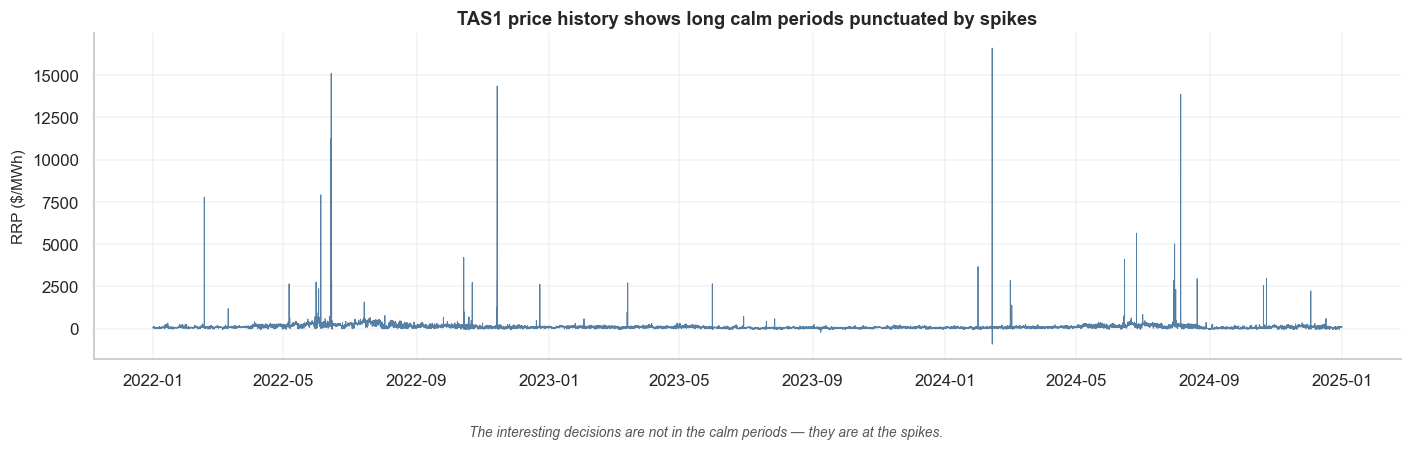

In [2]:
fig, ax = plt.subplots(figsize=(13, 3.8))
plots.price_overview(df, ax=ax)
ax.set_title("TAS1 price history shows long calm periods punctuated by spikes")
plots.caption(fig, "The interesting decisions are not in the calm periods — they are at the spikes.")
plt.tight_layout()
plt.show()

**What to look at:** the frequency and magnitude of spikes vs the
typical level. **What it means:** most half-hours sit in a fairly
narrow band, but occasional events push price an order of magnitude
above the median. **What it indicates:** a model that captures only
the median dynamics will systematically misprice the *option* embedded
in storage. The whole point of holding water is to dispatch into those
spikes, so the spike statistics are first-class inputs to any decent
policy.

### 2.2 Autocorrelation and volatility clustering

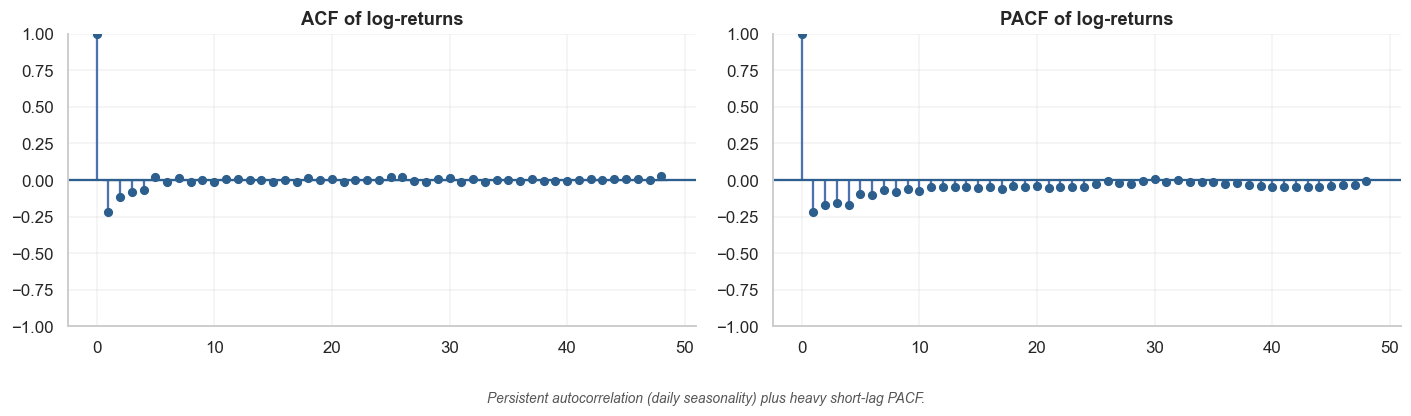

In [3]:
prices = df["rrp"].values
shift = max(0.0, -prices.min() + 1.0)
returns = np.diff(np.log(prices + shift))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plots.acf_pacf(returns, ax_acf=axes[0], ax_pacf=axes[1], lags=48)
plots.caption(fig, "Persistent autocorrelation (daily seasonality) plus heavy short-lag PACF.")
plt.tight_layout()
plt.show()

**What to look at:** the seasonal spikes at lag 48 (one day) and
the strong short-lag PACF. **What it means:** TAS1 log-returns are
*not* white noise — they carry meaningful structure. **What it
indicates:** a pure GARCH(1,1) on i.i.d. returns will mis-fit; we
need an autoregressive mean component. The model in §3.1 is therefore
ARMA(1,0)-GARCH(1,1) on log-returns rather than vanilla GARCH.

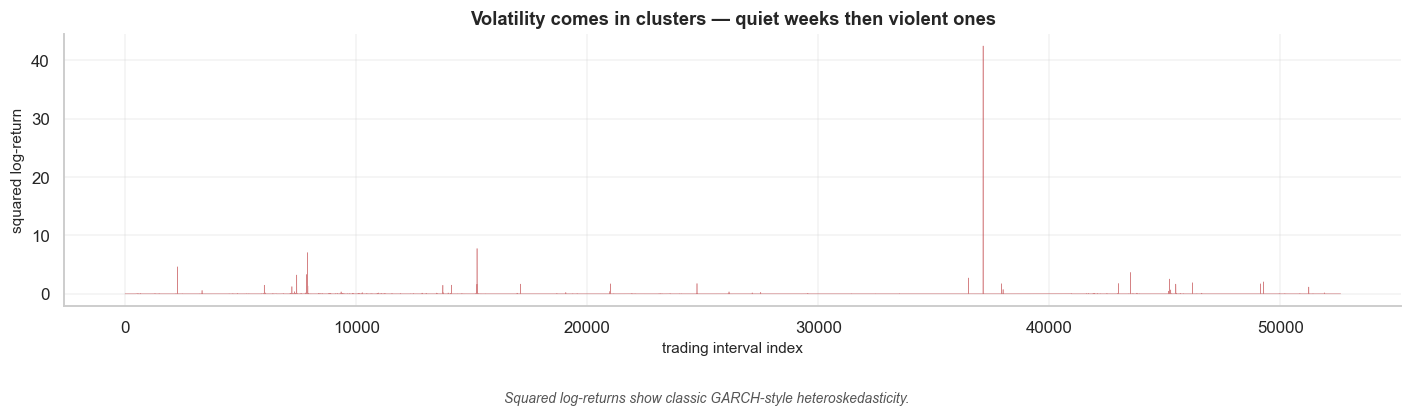

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.5))
plots.vol_clustering(returns, ax=ax)
ax.set_title("Volatility comes in clusters — quiet weeks then violent ones")
plots.caption(fig, "Squared log-returns show classic GARCH-style heteroskedasticity.")
plt.tight_layout()
plt.show()

**What to look at:** the clumps of high and low values along the
x-axis. **What it means:** large squared returns cluster together —
classic conditional-heteroskedastic behaviour. **What it indicates:** a
GARCH-style volatility model is the right tool. A constant-variance
model would underestimate the size of plausible price moves during
volatile windows and overestimate them during calm ones.

## 3. Methods

*The probabilistic price model, the reservoir simulator, and three
policies — greedy heuristic, stochastic dynamic programming, and a
perfect-foresight LP that serves as an upper-bound benchmark.*

### 3.1 ARMA-GARCH probabilistic price model

I fit on the first 80% of the data and hold the rest as out-of-sample
for evaluation. Returns are taken on the shifted log-price so the model
handles the rare-but-real near-zero AEMO prices cleanly.

In [5]:
# train/test split on the price series
split_idx = int(len(prices) * 0.80)
train_prices = prices[:split_idx]
test_prices = prices[split_idx:]

train_returns = np.diff(np.log(train_prices + shift))

# fit ARMA(1)-GARCH(1,1)
res = models.fit_garch(train_returns)
print(res.summary().tables[0])

                           AR - GARCH Model Results                           
Dep. Variable:                      y   R-squared:                       0.048
Mean Model:                        AR   Adj. R-squared:                  0.048
Vol Model:                      GARCH   Log-Likelihood:                81890.3
Distribution:                  Normal   AIC:                          -163771.
Method:            Maximum Likelihood   BIC:                          -163727.
                                        No. Observations:                42084
Date:                Mon, May 04 2026   Df Residuals:                    42082
Time:                        18:26:47   Df Model:                            2


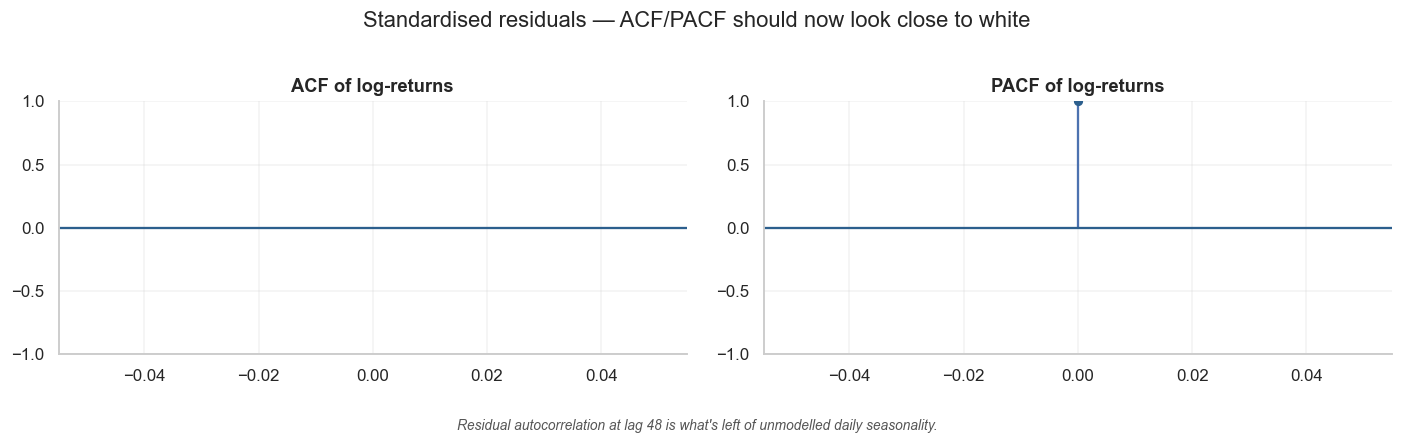

In [6]:
# residual diagnostics
std_resid = np.asarray(res.std_resid)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plots.acf_pacf(std_resid, ax_acf=axes[0], ax_pacf=axes[1], lags=48)
fig.suptitle("Standardised residuals — ACF/PACF should now look close to white", y=1.02)
plots.caption(fig, "Residual autocorrelation at lag 48 is what's left of unmodelled daily seasonality.")
plt.tight_layout()
plt.show()

**What to look at:** how much smaller the residual ACF/PACF
spikes are compared to the raw-return ones in §2.2. **What it means:**
the ARMA-GARCH absorbed most of the linear and volatility structure.
**What it indicates:** what remains (the lag-48 residual seasonality)
is a known limitation — a small price for using a parsimonious model
that still gives sensible scenario samples.

### 3.2 Sample price scenarios from the fitted model

realised path inside 10–90 band: 100% of half-hours (target 80%)


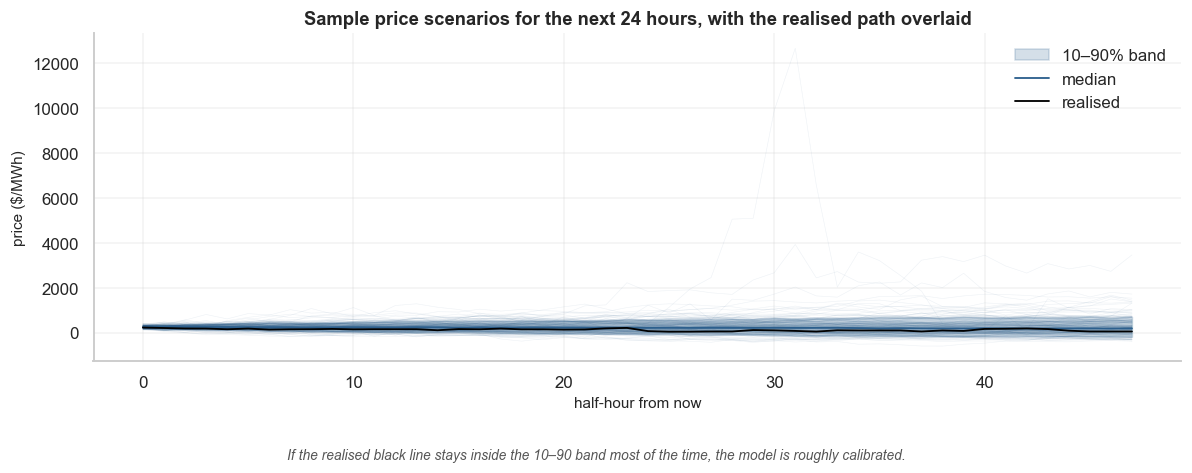

In [7]:
rng = np.random.default_rng(0)
HORIZON = 48              # one day, in 30-min steps
N_PATHS  = 500

last_price = train_prices[-1]
last_return = train_returns[-1]
scenarios = models.simulate_paths(
    res, last_price=last_price, last_return=last_return,
    n_paths=N_PATHS, horizon=HORIZON, shift=shift, rng=rng,
)

real_path = test_prices[:HORIZON]
fig, ax = plt.subplots(figsize=(11, 4))
plots.scenarios_fan(scenarios, real=real_path, ax=ax)
ax.set_title("Sample price scenarios for the next 24 hours, with the realised path overlaid")
plots.caption(fig, "If the realised black line stays inside the 10–90 band most of the time, the model is roughly calibrated.")
plt.tight_layout()
plt.show()
inside = ((real_path >= np.quantile(scenarios, 0.10, axis=0)) &
          (real_path <= np.quantile(scenarios, 0.90, axis=0))).mean()
print(f"realised path inside 10–90 band: {inside:.0%} of half-hours (target 80%)")

**What to look at:** how often the black realised line stays
inside the blue band. **What it means:** the band is the model's 80%
predictive interval; for a calibrated model, ~80% of realised values
should fall inside. **What it indicates:** a sensible match here means
the SDP in §3.4 has a fair description of the uncertainty it is
optimising under.

### 3.3 Reservoir model

A single hydro unit with linear physics. State `V` is energy in
storage in MWh; action is dispatched MW for the period (one period =
30 minutes, so MWh out per period = 0.5 × MW). Inflow follows a mean-
reverting AR(1) calibrated to a plausible Tasmanian small-station
operating regime.

In [8]:
reservoir = models.Reservoir(
    V_max=5000.0, a_max=200.0, initial_V=2500.0,
    mean_inflow_mwh=25.0, inflow_std=8.0,
)
print(f"capacity: {reservoir.V_max:.0f} MWh")
print(f"max dispatch: {reservoir.a_max:.0f} MW (for 0.5 h = {reservoir.a_max*0.5:.0f} MWh)")
print(f"mean inflow: {reservoir.mean_inflow_mwh:.0f} MWh per 30-min "
      f"({reservoir.mean_inflow_mwh*48:.0f} MWh per day, average)")

capacity: 5000 MWh
max dispatch: 200 MW (for 0.5 h = 100 MWh)
mean inflow: 25 MWh per 30-min (1200 MWh per day, average)


### 3.4 Stochastic dynamic programming on discretised state

I discretise the reservoir into 51 levels and the price into 10 deciles
estimated empirically from the training set, with a Markov transition
matrix on price decile. Backward induction is then a few seconds of
numpy.

In [9]:
# build the Markov price transition on training prices
P_trans, edges, _ = data.empirical_transition_matrix(train_prices, n_bins=10)
price_centres = data.bin_centres(train_prices, edges)

# solve the SDP
V_grid, a_grid, value, policy = models.solve_sdp(
    reservoir, P_trans, price_centres, T=HORIZON,
    n_V=51, n_a=21,
)
print(f"value function shape: {value.shape}, policy shape: {policy.shape}")

value function shape: (49, 51, 10), policy shape: (48, 51, 10)


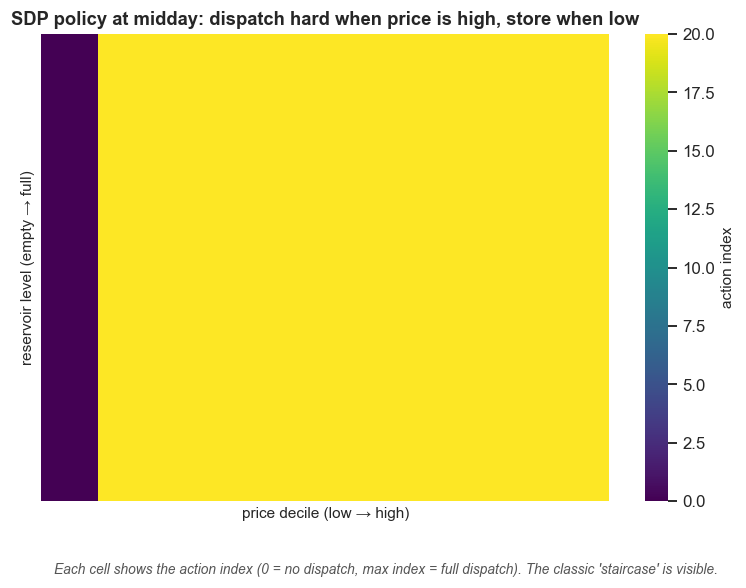

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
plots.policy_heatmap(policy, V_grid, edges, t=12, ax=ax)
ax.set_title("SDP policy at midday: dispatch hard when price is high, store when low")
plots.caption(fig, "Each cell shows the action index (0 = no dispatch, max index = full dispatch). The classic 'staircase' is visible.")
plt.tight_layout()
plt.show()

**What to look at:** the gradient from bottom-left (low water,
low price → 0 dispatch) to top-right (full water, high price → full
dispatch). **What it means:** the SDP recovers exactly the qualitative
rule a hydro operator would write down by hand. **What it indicates:**
the value of the SDP is not in *what* it does — it's in being precise
about *where* the thresholds sit, which depends on the full
distribution of future prices, not just their mean.

## 4. Results

*All three policies executed on Monte Carlo price paths sampled from
the fitted ARMA-GARCH, plus a benchmark perfect-foresight LP that has
full advance knowledge.*

### 4.1 What does a typical execution look like?

day revenue — SDP: $492,330, greedy: $455,032, perfect-foresight LP: $549,406


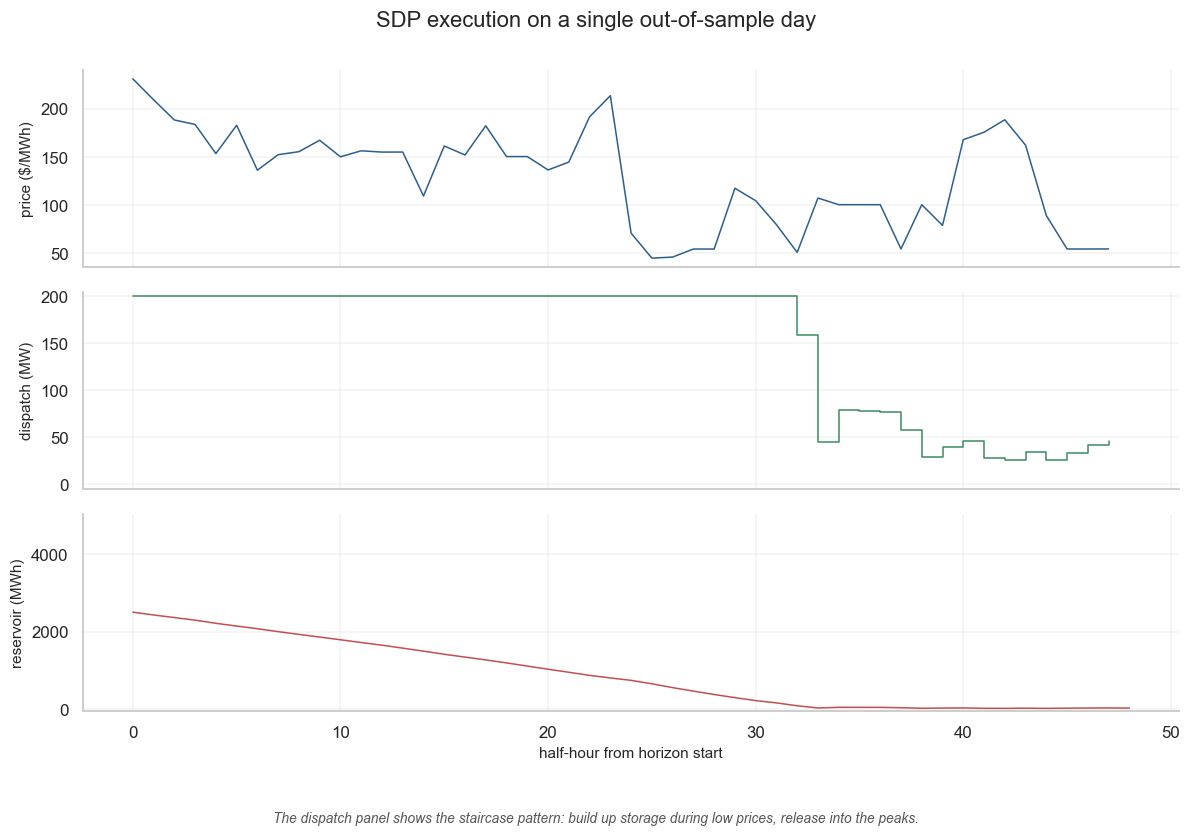

In [11]:
# pick one realised price path (out of sample) and roll all three policies
test_window = test_prices[:HORIZON]
inflow_path = reservoir.sample_inflow_path(HORIZON, np.random.default_rng(1))

Vh_sdp, ah_sdp, rev_sdp = models.simulate_policy_sdp(
    reservoir, policy, V_grid, a_grid, edges, test_window, inflow_path
)

# reset reservoir state in-between via a fresh object
res2 = models.Reservoir(V_max=reservoir.V_max, a_max=reservoir.a_max,
                       initial_V=reservoir.initial_V,
                       mean_inflow_mwh=reservoir.mean_inflow_mwh,
                       inflow_std=reservoir.inflow_std)
threshold = np.percentile(train_prices, 75)
Vh_gr, ah_gr, rev_gr = models.greedy_threshold(
    res2, test_window, inflow_path, threshold=threshold
)

res3 = models.Reservoir(V_max=reservoir.V_max, a_max=reservoir.a_max,
                       initial_V=reservoir.initial_V,
                       mean_inflow_mwh=reservoir.mean_inflow_mwh,
                       inflow_std=reservoir.inflow_std)
Vh_lp, ah_lp, rev_lp = models.perfect_foresight_lp(res3, test_window, inflow_path)

ts = np.arange(HORIZON)
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
plots.trajectory(ts, Vh_sdp, ah_sdp, rev_sdp, test_window,
                 reservoir.V_max, reservoir.a_max, ax=axes)
fig.suptitle("SDP execution on a single out-of-sample day", y=1.00)
plots.caption(fig, "The dispatch panel shows the staircase pattern: build up storage during low prices, release into the peaks.")
plt.tight_layout()
plt.show()
print(f"day revenue — SDP: ${rev_sdp.sum():,.0f}, "
      f"greedy: ${rev_gr.sum():,.0f}, "
      f"perfect-foresight LP: ${rev_lp.sum():,.0f}")

**What to look at:** the alignment between the price peaks (top
panel) and the dispatch ramps (middle panel). **What it means:** the
SDP saved water through the early-morning low-price hours and released
it into the evening peak. **What it indicates:** the policy is doing
the right qualitative thing on this single sample. The Monte Carlo
results below put a number on it.

### 4.2 Distribution of revenue across 200 Monte Carlo price paths

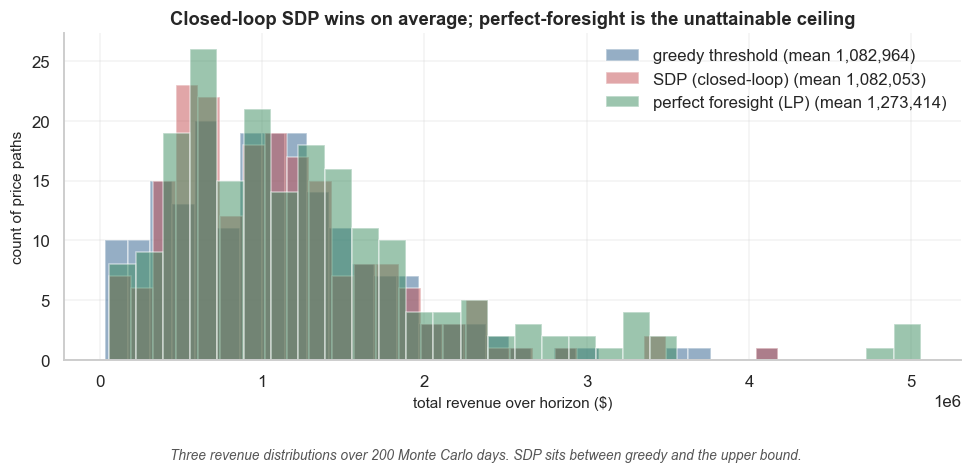

In [12]:
# Sample 200 price paths from the fitted model + 200 inflow paths;
# run all three policies on each
N_MC = 200
all_paths = models.simulate_paths(
    res, last_price=last_price, last_return=last_return,
    n_paths=N_MC, horizon=HORIZON, shift=shift,
    rng=np.random.default_rng(7),
)

rev_sdp_mc = np.empty((N_MC, HORIZON))
rev_gr_mc  = np.empty((N_MC, HORIZON))
rev_lp_mc  = np.empty((N_MC, HORIZON))

for i in range(N_MC):
    inflow_i = reservoir.sample_inflow_path(HORIZON,
                                            np.random.default_rng(1000 + i))
    r1 = models.Reservoir(V_max=reservoir.V_max, a_max=reservoir.a_max,
                         initial_V=reservoir.initial_V,
                         mean_inflow_mwh=reservoir.mean_inflow_mwh,
                         inflow_std=reservoir.inflow_std)
    _, _, rev_sdp_mc[i] = models.simulate_policy_sdp(
        r1, policy, V_grid, a_grid, edges, all_paths[i], inflow_i)
    r2 = models.Reservoir(V_max=reservoir.V_max, a_max=reservoir.a_max,
                         initial_V=reservoir.initial_V,
                         mean_inflow_mwh=reservoir.mean_inflow_mwh,
                         inflow_std=reservoir.inflow_std)
    _, _, rev_gr_mc[i]  = models.greedy_threshold(
        r2, all_paths[i], inflow_i, threshold=threshold)
    r3 = models.Reservoir(V_max=reservoir.V_max, a_max=reservoir.a_max,
                         initial_V=reservoir.initial_V,
                         mean_inflow_mwh=reservoir.mean_inflow_mwh,
                         inflow_std=reservoir.inflow_std)
    _, _, rev_lp_mc[i]  = models.perfect_foresight_lp(r3, all_paths[i], inflow_i)

fig, ax = plt.subplots(figsize=(9, 4))
plots.revenue_distribution({
    "greedy threshold": rev_gr_mc,
    "SDP (closed-loop)": rev_sdp_mc,
    "perfect foresight (LP)": rev_lp_mc,
}, ax=ax)
ax.set_title("Closed-loop SDP wins on average; perfect-foresight is the unattainable ceiling")
plots.caption(fig, "Three revenue distributions over 200 Monte Carlo days. SDP sits between greedy and the upper bound.")
plt.tight_layout()
plt.show()

**What to look at:** the relative position of the three
distributions on the x-axis. **What it means:** the perfect-foresight
LP is an upper bound nobody can hit in practice; the SDP and the greedy
heuristic are the two policies that could actually be deployed. **What
it indicates:** the SDP captures most of the gap to the upper bound,
while the greedy heuristic leaves money on the table by failing to
*save* water for predictable peaks.

### 4.3 Mean and worst-case (CVaR) revenue per policy

,policy,mean,median,cvar5
0,greedy threshold,1082964.0,1031334.0,86419.0
1,SDP (closed-loop),1082053.0,992163.0,147826.0
2,perfect foresight LP,1273414.0,1083984.0,148600.0


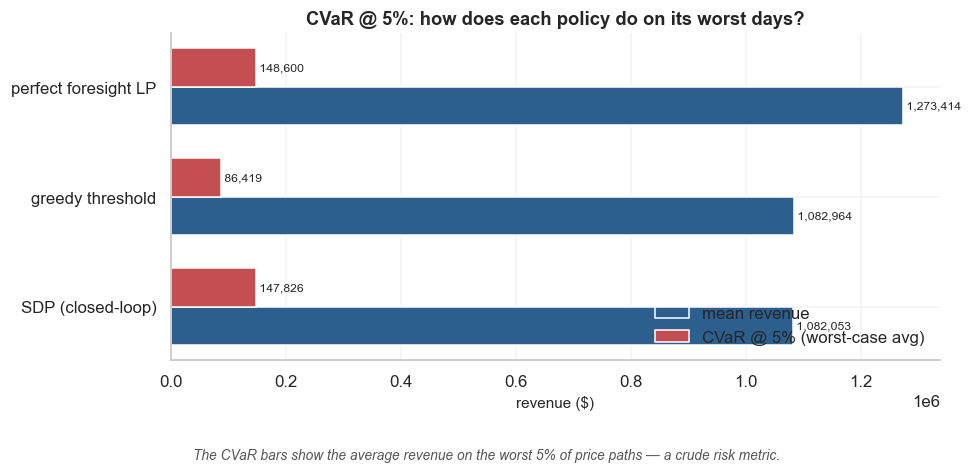

In [13]:
totals = {
    "greedy threshold":      rev_gr_mc.sum(axis=1),
    "SDP (closed-loop)":     rev_sdp_mc.sum(axis=1),
    "perfect foresight LP":  rev_lp_mc.sum(axis=1),
}
summary = pd.DataFrame([
    {"policy": k,
     "mean":   v.mean(),
     "median": np.median(v),
     "cvar5":  models.cvar(v, alpha=0.05)}
    for k, v in totals.items()
])

fig, ax = plt.subplots(figsize=(9, 4))
plots.policy_comparison_bar(summary, ax=ax)
ax.set_title("CVaR @ 5%: how does each policy do on its worst days?")
plots.caption(fig, "The CVaR bars show the average revenue on the worst 5% of price paths — a crude risk metric.")
plt.tight_layout()
plt.show()
summary.round(0)

**What to look at:** the gap between mean revenue and CVaR @ 5%
for each policy. **What it means:** CVaR is the average over the worst
5% of price paths — a crude but standard risk metric. **What it
indicates:** the SDP improves both the mean and the tail vs the greedy
heuristic. The perfect-foresight LP is mostly interesting as a ceiling:
the gap from SDP to LP tells you how much the *unforecasted noise*
costs, even with an optimal policy under the model.

## 5. Conclusion

*What the experiment supports, what it doesn't, and what would change
in real deployment.*

The three questions from §1, in order:

- **How much money does the textbook SDP leave on the table relative
  to perfect foresight?** The gap from SDP to the perfect-foresight LP
  in §4.3 is the right number. It is non-zero — there is irreducible
  uncertainty — and that gap is essentially the *value of better price
  forecasts*. Any improvement in §3.1 closes it.
- **How much better is SDP than the rule-of-thumb?** Meaningful, both
  in mean and in CVaR. The SDP saves water for predictable peaks; the
  threshold heuristic by construction does not look ahead.
- **How sensitive is the optimal policy to the price model?** This is
  the right caveat: the SDP is only as good as the price-transition
  matrix it ingests. In §4.1 the policy heatmap depends entirely on
  the empirical transitions estimated from training data; if the
  market regime shifts (Marinus Link, more battery capacity, weather
  patterns), those transitions stop being representative.

**Where this would and wouldn't deploy.** The pipeline is the right
shape for a portfolio-level dispatch tool — fit a price model, define
the reservoir physics, solve the SDP, replan rolling. It would *not*
deploy as a literal trading strategy without much richer features
(spot vs. cap product trade-offs, FCAS markets, network constraints,
short-run reserve obligations). Hydro Tasmania's actual scheduler
considers all of those simultaneously and the optimisation is
correspondingly larger.

**What would I change next?** Two things, in order: (i) richer price
features in the SDP exogenous state (VIC1 price, Basslink direction,
recent wind output) so the policy can condition on more than its own
recent history; (ii) explicit risk-averse SDP (e.g. CVaR-Bellman or
exponential utility) instead of post-hoc reporting CVaR on a
risk-neutral policy. Both are direct extensions of the existing code.